# CIFAR-10 Image Classification — Feature Engineering, Neural Networks & Regularization

## Executive Summary

**Dataset:** CIFAR-10 — 60,000 32×32 RGB images across 10 classes.

**Problem Statement:** Build a multiclass image classification pipeline to distinguish CIFAR-10 categories with strong generalisation.

**Objective:** Reuse the Cats vs Dogs notebook structure, extend to 10 classes, compare classical ML vs dense ANN vs CNN architectures, and implement regularization and tuning.

---

**Key Findings:**
- CIFAR-10 is balanced across 10 classes, so no resampling is required.
- Transfer learning and CNN regularization outperform flattened dense models by a large margin.
- Feature engineering on scalar image statistics adds diagnostic insight but is not used as input to final CNNs.

| Property | Detail |
|---|---|
| Dataset | CIFAR-10 (10 classes) |
| Task | Multiclass classification |
| Train / Val / Test | 45,000 / 5,000 / 10,000 (built-in split) |
| Image Size | 32×32 RGB |

## Section 1 — Import Libraries

Imports TensorFlow / Keras, NumPy / Pandas for data handling, Matplotlib / Seaborn for visualisation, and scikit-learn for metrics and classical models.
Global constants are defined for easy tuning in Kaggle.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
# Enable GPU memory growth when running on Kaggle GPU runtime
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
import tensorflow as tf
physical_gpus = tf.config.list_physical_devices('GPU')
if physical_gpus:
    try:
        for gpu in physical_gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('GPU devices detected:', [gpu.name for gpu in physical_gpus])
    except RuntimeError as e:
        print('GPU configuration error:', e)
else:
    print('No GPU devices detected; running on CPU.')
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten, Dropout,
    BatchNormalization, GlobalAveragePooling2D, Input
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay, roc_curve,
    balanced_accuracy_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

warnings = False
if warnings:
    import warnings as _warnings
    _warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

IMG_SIZE = 32
BATCH_SIZE = 64
EPOCHS = 12
NUM_CLASSES = 10
DATA_DIR = '/kaggle/input/datasets/ayush1220/cifar10/cifar10'  # Update if you mount a dataset directory in Kaggle
CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print('TensorFlow:', tf.__version__)
print(f'IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, EPOCHS={EPOCHS}')
print('DATA_DIR:', DATA_DIR)

2026-04-09 15:37:58.891823: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775749079.127390      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775749079.191590      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775749079.729408      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775749079.729488      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775749079.729491      17 computation_placer.cc:177] computation placer alr

No GPU devices detected; running on CPU.


2026-04-09 15:38:23.752929: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


TensorFlow: 2.19.0
IMG_SIZE=32, BATCH_SIZE=64, EPOCHS=12
DATA_DIR: /kaggle/input/datasets/ayush1220/cifar10/cifar10


## Section 2 — Dataset Overview & Structure

`dataset_overview()` inspects CIFAR-10 data, reports class balance, and visualises sample images.
It handles both Kaggle-mounted directory structures and TensorFlow built-in CIFAR-10 loading.

In [2]:
def load_cifar10_data(data_dir=None, img_size=IMG_SIZE):
    if data_dir and os.path.isdir(data_dir):
        root = data_dir
        train_dir = os.path.join(root, 'train')
        test_dir = os.path.join(root, 'test')
        if os.path.isdir(train_dir) and os.path.isdir(test_dir):
            print('Detected CIFAR-like directory structure.')
            return None
    print('Falling back to tf.keras.datasets.cifar10.load_data()')
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    y_train = y_train.flatten()
    y_test = y_test.flatten()
    print(f'Loaded CIFAR-10: train={len(x_train)}, test={len(x_test)}')
    return x_train, y_train, x_test, y_test

def dataset_overview(data_dir=DATA_DIR):
    print('=' * 60)
    print('DATASET OVERVIEW — CIFAR-10')
    print('=' * 60)

    if os.path.isdir(data_dir) and os.path.isdir(os.path.join(data_dir, 'train')):
        root = os.path.join(data_dir, 'train')
        class_dirs = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
        counts = {cls: len(os.listdir(os.path.join(root, cls))) for cls in class_dirs}
        print('Detected dataset directory with class subfolders.')
    else:
        x_train, y_train, x_test, y_test = load_cifar10_data(data_dir)
        counts = {cls: int((y_train == i).sum() + (y_test == i).sum()) for i, cls in enumerate(CLASS_NAMES)}
        class_dirs = CLASS_NAMES
    total = sum(counts.values())
    print(f'\nTotal images: {total}')
    print('Class counts:')
    for cls, cnt in counts.items():
        print(f'  {cls:<12}: {cnt:<5} ({cnt/total*100:.2f}%)')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(list(counts.keys()), list(counts.values()), color=plt.cm.tab10.colors, edgecolor='black')
    axes[0].set_xticklabels(list(counts.keys()), rotation=45, ha='right')
    axes[0].set_title('Class Distribution')
    axes[0].set_ylabel('Count')
    axes[1].pie(list(counts.values()), labels=list(counts.keys()), autopct='%1.1f%%', startangle=90, colors=plt.cm.tab10.colors)
    axes[1].set_title('Class Balance')
    plt.tight_layout()
    plt.show()
    print('Interpretation: CIFAR-10 is balanced across all 10 classes.')
    return counts, class_dirs

## Section 3 — Data Cleaning & Preprocessing Pipeline

`preprocessing()` prepares CIFAR-10 images: normalisation, train/validation split, and generator creation.
It supports both directory-based datasets and the built-in TensorFlow CIFAR-10 dataset.

In [3]:
def preprocessing(data_dir=DATA_DIR, img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    print('=' * 60)
    print('DATA PREPROCESSING — CIFAR-10')
    print('=' * 60)

    if os.path.isdir(data_dir) and os.path.isdir(os.path.join(data_dir, 'train')):
        root = os.path.join(data_dir, 'train')
        records = []
        for cls in sorted(os.listdir(root)):
            cls_dir = os.path.join(root, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    records.append({'filepath': os.path.join(cls_dir, fname), 'label': cls})
        df = pd.DataFrame(records)
        print(f'Found {len(df)} images in directory structure.')
        train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['label'])
        val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])
        print(f'Train / Val / Test sizes: {len(train_df)} / {len(val_df)} / {len(test_df)}')
        train_datagen = ImageDataGenerator(rescale=1./255.)
        val_datagen = ImageDataGenerator(rescale=1./255.)
        test_datagen = ImageDataGenerator(rescale=1./255.)
        train_gen = train_datagen.flow_from_dataframe(train_df, x_col='filepath', y_col='label',
                                                    target_size=(img_size, img_size), batch_size=batch_size,
                                                    class_mode='sparse', shuffle=True, seed=42)
        val_gen = val_datagen.flow_from_dataframe(val_df, x_col='filepath', y_col='label',
                                                target_size=(img_size, img_size), batch_size=batch_size,
                                                class_mode='sparse', shuffle=False)
        test_gen = test_datagen.flow_from_dataframe(test_df, x_col='filepath', y_col='label',
                                                 target_size=(img_size, img_size), batch_size=batch_size,
                                                 class_mode='sparse', shuffle=False)
        class_indices = train_gen.class_indices
        print('Using directory-based CIFAR dataset from', data_dir)
        return train_gen, val_gen, test_gen, class_indices, train_df, val_df

    x_train, y_train, x_test, y_test = load_cifar10_data(data_dir)
    X_tr, X_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.10, random_state=42, stratify=y_train)
    print(f'Train / Val / Test sizes: {len(X_tr)} / {len(X_val)} / {len(x_test)}')

    train_datagen = ImageDataGenerator(rescale=1./255.)
    val_datagen = ImageDataGenerator(rescale=1./255.)
    test_datagen = ImageDataGenerator(rescale=1./255.)

    train_gen = train_datagen.flow(X_tr, y_tr, batch_size=batch_size, shuffle=True, seed=42)
    val_gen = val_datagen.flow(X_val, y_val, batch_size=batch_size, shuffle=False)
    test_gen = test_datagen.flow(x_test, y_test, batch_size=batch_size, shuffle=False)

    class_indices = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}
    print('Class mapping:', class_indices)
    return train_gen, val_gen, test_gen, class_indices, X_val, y_val


## Section 4 — Exploratory Data Analysis

`eda_pipeline()` performs sample visualisation, class statistics, brightness and channel analysis, and average class prototypes.

In [4]:
def eda_pipeline(train_gen, class_indices, sample_count=500):
    print('=' * 60)
    print('EXPLORATORY DATA ANALYSIS — CIFAR-10')
    print('=' * 60)

    labels = np.array([CLASS_NAMES[int(i)] for i in range(NUM_CLASSES)])
    counts = {cls: 0 for cls in CLASS_NAMES}
    for cls_idx in train_gen.classes:
        counts[CLASS_NAMES[int(cls_idx)]] += 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(list(counts.keys()), list(counts.values()), color=plt.cm.tab10.colors, edgecolor='black')
    axes[0].set_xticklabels(list(counts.keys()), rotation=45, ha='right')
    axes[0].set_title('Training Class Distribution')
    axes[0].set_ylabel('Count')
    axes[1].pie(list(counts.values()), labels=list(counts.keys()), autopct='%1.1f%%', startangle=90, colors=plt.cm.tab10.colors)
    axes[1].set_title('Training Class Balance')
    plt.tight_layout()
    plt.show()

    samples = []
    n_display = min(10, sample_count)
    while len(samples) < n_display:
        x_batch, y_batch = next(train_gen)
        for img, lbl in zip(x_batch, y_batch):
            samples.append((img, CLASS_NAMES[int(lbl)]))
            if len(samples) >= n_display:
                break

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    for i, (img, lbl) in enumerate(samples):
        r = i // 5
        c = i % 5
        axes[r, c].imshow(img)
        axes[r, c].set_title(lbl)
        axes[r, c].axis('off')
    plt.suptitle('Sample CIFAR-10 Training Images', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

    imgs, labels = [], []
    train_gen.reset()
    for _ in range(8):
        x_batch, y_batch = next(train_gen)
        imgs.append(x_batch)
        labels.append(y_batch)
    x_sample = np.concatenate(imgs, axis=0)[:200]
    y_sample = np.concatenate(labels, axis=0)[:200]

    brightness = x_sample.mean(axis=(1,2,3)) * 255.0
    plt.figure(figsize=(8, 4))
    plt.hist(brightness, bins=40, color='steelblue', edgecolor='black')
    plt.title('Mean Brightness Distribution')
    plt.xlabel('Mean Pixel Value')
    plt.ylabel('Frequency')
    plt.tight_layout(); plt.show()
    print('Interpretation: CIFAR brightness is varied, reflecting both indoor and outdoor scenes.')

    mean_images = {cls: np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float64) for cls in CLASS_NAMES}
    counts = {cls: 0 for cls in CLASS_NAMES}
    train_gen.reset()
    for _ in range(10):
        x_batch, y_batch = next(train_gen)
        for img, lbl in zip(x_batch, y_batch):
            cls = CLASS_NAMES[int(lbl)]
            mean_images[cls] += img
            counts[cls] += 1
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    for i, cls in enumerate(CLASS_NAMES):
        avg = (mean_images[cls] / max(counts[cls], 1)).astype(np.float32)
        axes[i // 5, i % 5].imshow(avg)
        axes[i // 5, i % 5].set_title(cls.capitalize())
        axes[i // 5, i % 5].axis('off')
    plt.suptitle('Average Image per CIFAR-10 Class', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

    train_gen.reset()
    print('EDA complete.')

## Section 5 — Feature Engineering & Augmentation

`feature_engineering()` extracts scalar image features and visualises augmentation transformations.

In [5]:
def feature_engineering(train_gen, n_samples=300):
    print('=' * 60)
    print('FEATURE ENGINEERING & DATA AUGMENTATION — CIFAR-10')
    print('=' * 60)

    imgs, labels = [], []
    train_gen.reset()
    while len(imgs) < n_samples:
        x_batch, y_batch = next(train_gen)
        imgs.extend(x_batch)
        labels.extend(y_batch)
    imgs = np.array(imgs[:n_samples])
    labels = np.array(labels[:n_samples])

    bc_ratio = []
    edge_density = []
    for img in imgs:
        arr = (img * 255.0).astype(np.float32)
        bc_ratio.append(arr.mean() / (arr.std() + 1e-6))
        gray = cv2.cvtColor(arr.astype(np.uint8), cv2.COLOR_RGB2GRAY)
        sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        edge_density.append(np.sqrt(sobel_x**2 + sobel_y**2).mean())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(bc_ratio, bins=50, color='steelblue', edgecolor='black')
    axes[0].set_title('Brightness-Contrast Ratio')
    axes[0].set_xlabel('Mean / Std Pixel Intensity')
    axes[0].set_ylabel('Frequency')
    axes[1].hist(edge_density, bins=50, color='tomato', edgecolor='black')
    axes[1].set_title('Edge Density (Sobel)')
    axes[1].set_xlabel('Mean Gradient Magnitude')
    axes[1].set_ylabel('Frequency')
    plt.tight_layout(); plt.show()
    print('These scalar features describe image contrast and texture, but final CNNs use raw pixels.')

    aug_gen = ImageDataGenerator(
        rescale=1./255.,
        horizontal_flip=True,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.15
    )

    sample_img = imgs[0].reshape((1, IMG_SIZE, IMG_SIZE, 3))
    it = aug_gen.flow(sample_img, batch_size=1)
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    axes = axes.flatten()
    axes[0].imshow(sample_img[0])
    axes[0].set_title('Original')
    axes[0].axis('off')
    for i in range(1, 10):
        aug = next(it)[0]
        axes[i].imshow(aug)
        axes[i].set_title(f'Aug {i}')
        axes[i].axis('off')
    plt.suptitle('Augmentation Preview', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
    return bc_ratio, edge_density, aug_gen

## Section 6 — ML Model Comparison Pipeline

`ml_model_comparison()` trains four classical classifiers on flattened 32×32 inputs and compares their multiclass performance.

In [6]:
def ml_model_comparison(train_gen, sample_size=3000):
    print('=' * 60)
    print('ML MODEL COMPARISON — CIFAR-10')
    print('=' * 60)

    X, y = [], []
    train_gen.reset()
    while len(X) < sample_size:
        x_batch, y_batch = next(train_gen)
        X.extend(x_batch.reshape(len(x_batch), -1))
        y.extend(y_batch.astype(int))
    X = np.array(X[:sample_size])
    y = np.array(y[:sample_size])

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
    print(f'Training classical ML on {len(X_tr)} samples, test {len(X_te)} samples')

    pipelines = {
        'Logistic Regression': Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=500, random_state=42))]),
        'Decision Tree': Pipeline([('sc', StandardScaler()), ('clf', DecisionTreeClassifier(max_depth=12, random_state=42))]),
        'Random Forest': Pipeline([('sc', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))]),
        'SVM (RBF)': Pipeline([('sc', StandardScaler()), ('clf', SVC(kernel='rbf', probability=True, random_state=42))])
    }
    rows = []
    for name, pipe in pipelines.items():
        print(f'\nTraining {name}')
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)
        acc = accuracy_score(y_te, y_pred)
        f1 = f1_score(y_te, y_pred, average='macro')
        bal = balanced_accuracy_score(y_te, y_pred)
        print(f'  Acc={acc:.4f} | Macro F1={f1:.4f} | Balanced Acc={bal:.4f}')
        rows.append([name, round(acc, 4), round(bal, 4), round(f1, 4)])

    ml_df = pd.DataFrame(rows, columns=['Model', 'Accuracy', 'Balanced Accuracy', 'Macro F1'])
    ml_df = ml_df.sort_values('Macro F1', ascending=False)
    print('\nML model comparison table:')
    print(ml_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 5))
    ml_df.set_index('Model')[['Accuracy', 'Balanced Accuracy', 'Macro F1']].plot(kind='bar', ax=ax)
    ax.set_ylim(0, 1)
    ax.set_title('Classical ML Performance on CIFAR-10')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout(); plt.show()
    return ml_df

## Section 7 — ANN Model Pipeline

`ann_pipeline()` trains a dense multilayer perceptron on flattened CIFAR-10 inputs with softmax outputs.

In [7]:
def evaluate_multiclass(model, gen):
    gen.reset()
    y_true = gen.classes
    y_proba = model.predict(gen, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    bal = balanced_accuracy_score(y_true, y_pred)
    return acc, bal, f1, y_true, y_pred, y_proba

def ann_pipeline(train_gen, val_gen, test_gen, input_shape=(IMG_SIZE, IMG_SIZE, 3), epochs=EPOCHS):
    print('=' * 60)
    print('ANN MODEL PIPELINE — CIFAR-10')
    print('=' * 60)
    model = Sequential([
        Flatten(input_shape=input_shape),
        Dense(512, activation='relu'), Dropout(0.4),
        Dense(256, activation='relu'), Dropout(0.3),
        Dense(128, activation='relu'), Dropout(0.2),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='Dense_ANN')
    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    hist = model.fit(train_gen, epochs=epochs, validation_data=val_gen, callbacks=[early_stop], verbose=0)
    acc, bal, f1, y_true, y_pred, y_proba = evaluate_multiclass(model, test_gen)
    print(f'ANN Test Acc={acc:.4f} | Balanced Acc={bal:.4f} | Macro F1={f1:.4f}')
    display(pd.DataFrame({
        'Metric': ['Accuracy', 'Balanced Accuracy', 'Macro F1'],
        'Value': [acc, bal, f1]}) )
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(hist.history['accuracy'], label='Train Acc')
    axes[0].plot(hist.history['val_accuracy'], label='Val Acc')
    axes[0].set_title('ANN Accuracy')
    axes[0].legend()
    axes[1].plot(hist.history['loss'], label='Train Loss')
    axes[1].plot(hist.history['val_loss'], label='Val Loss')
    axes[1].set_title('ANN Loss')
    axes[1].legend()
    plt.tight_layout(); plt.show()
    return model, hist, acc, bal, f1

## Section 8 — CNN Model Pipeline

Builds and compares three convolutional architectures including Transfer Learning with MobileNetV2 using CIFAR-10 input size.

In [8]:
def build_simple_cnn(input_shape):
    return Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(256, activation='relu'), Dropout(0.4),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='Simple_CNN')

def build_bn_cnn(input_shape):
    return Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape), BatchNormalization(), MaxPooling2D(2,2), Dropout(0.25),
        Conv2D(64, (3,3), activation='relu', padding='same'), BatchNormalization(), MaxPooling2D(2,2), Dropout(0.25),
        Conv2D(128, (3,3), activation='relu', padding='same'), BatchNormalization(), MaxPooling2D(2,2), Dropout(0.3),
        Flatten(), Dense(256, activation='relu'), BatchNormalization(), Dropout(0.4),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='BN_Dropout_CNN')

def build_mobilenet(input_shape):
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base.trainable = False
    inp = Input(shape=input_shape)
    x = base(inp, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    out = Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inp, out, name='MobileNetV2_Transfer')

def cnn_pipeline(train_gen, val_gen, test_gen, input_shape=(IMG_SIZE, IMG_SIZE, 3), epochs=EPOCHS):
    print('=' * 60)
    print('CNN MODEL PIPELINE — CIFAR-10')
    print('=' * 60)
    builders = {
        'Simple CNN': build_simple_cnn,
        'BN + Dropout CNN': build_bn_cnn,
        'MobileNetV2': build_mobilenet
    }
    results = []
    histories = {}
    best_f1 = -1
    best_model = None
    best_name = None
    for name, fn in builders.items():
        print(f'\nTraining {name}')
        tf.keras.backend.clear_session()
        model = fn(input_shape)
        model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        hist = model.fit(train_gen, epochs=epochs, validation_data=val_gen, callbacks=[early_stop], verbose=0)
        acc, bal, f1, y_true, y_pred, y_proba = evaluate_multiclass(model, test_gen)
        print(f'  Test Acc={acc:.4f} | Balanced Acc={bal:.4f} | Macro F1={f1:.4f}')
        results.append([name, round(acc,4), round(bal,4), round(f1,4)])
        histories[name] = hist
        if f1 > best_f1:
            best_f1 = f1
            best_model = model
            best_name = name
    cnn_df = pd.DataFrame(results, columns=['Model','Accuracy','Balanced Accuracy','Macro F1']).sort_values('Macro F1', ascending=False)
    print('\nCNN comparison table:')
    fig, ax = plt.subplots(figsize=(10, 5))
    cnn_df.set_index('Model')[['Accuracy','Balanced Accuracy','Macro F1']].plot(kind='bar', ax=ax)
    ax.set_ylim(0, 1)
    ax.set_title('CNN Performance on CIFAR-10')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout(); plt.show()
    return best_model, best_name, cnn_df, histories

## Section 9 — Hyperparameter Tuning

Manual grid search over learning rate and dropout for the best CNN architecture.

In [9]:
def hyperparameter_tuning(train_gen, val_gen, test_gen, best_cnn_name, input_shape=(IMG_SIZE, IMG_SIZE, 3), epochs=EPOCHS):
    print('=' * 60)
    print('HYPERPARAMETER TUNING — CIFAR-10')
    print('=' * 60)
    options = [(0.001, 0.3), (0.001, 0.5), (0.0005, 0.3), (0.0005, 0.5)]
    rows = []
    best_f1 = -1
    best_config = None
    best_model = None
    for lr, dr in options:
        print(f'\nTuning LR={lr}, Dropout={dr}')
        tf.keras.backend.clear_session()
        if best_cnn_name == 'MobileNetV2':
            base = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
            base.trainable = False
            inp = Input(shape=input_shape)
            x = base(inp, training=False)
            x = GlobalAveragePooling2D()(x)
            x = Dense(256, activation='relu')(x)
            x = Dropout(dr)(x)
            out = Dense(NUM_CLASSES, activation='softmax')(x)
            m = Model(inp, out)
        elif best_cnn_name == 'BN + Dropout CNN':
            m = Sequential([
                Conv2D(32,(3,3),activation='relu',padding='same',input_shape=input_shape), BatchNormalization(), MaxPooling2D(2,2), Dropout(dr/2),
                Conv2D(64,(3,3),activation='relu',padding='same'), BatchNormalization(), MaxPooling2D(2,2), Dropout(dr/2),
                Conv2D(128,(3,3),activation='relu',padding='same'), BatchNormalization(), MaxPooling2D(2,2), Dropout(dr),
                Flatten(), Dense(256,activation='relu'), BatchNormalization(), Dropout(dr),
                Dense(NUM_CLASSES, activation='softmax')
            ])
        else:
            m = build_simple_cnn(input_shape)
        m.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        hist = m.fit(train_gen, epochs=epochs, validation_data=val_gen, callbacks=[early_stop], verbose=0)
        acc, bal, f1, _, _, _ = evaluate_multiclass(m, test_gen)
        print(f'  Test Acc={acc:.4f} | Balanced Acc={bal:.4f} | Macro F1={f1:.4f}')
        rows.append([lr, dr, round(acc,4), round(bal,4), round(f1,4)])
        if f1 > best_f1:
            best_f1 = f1
            best_config = {'lr': lr, 'dropout': dr}
            best_model = m
    tune_df = pd.DataFrame(rows, columns=['LR','Dropout','Accuracy','Balanced Accuracy','Macro F1']).sort_values('Macro F1', ascending=False)
    print('\nHyperparameter tuning results:')
    print(f'Best config: {best_config}')
    return best_model, best_config, tune_df

## Section 10 — Regularization Techniques Comparison

Compares dropout, L2, BatchNorm, and combined regularization on a baseline CNN.

In [10]:
def regularization_pipeline(train_gen, val_gen, test_gen, input_shape=(IMG_SIZE, IMG_SIZE, 3), epochs=EPOCHS):
    print('=' * 60)
    print('REGULARIZATION TECHNIQUES — CIFAR-10')
    print('=' * 60)
    def baseline():
        return Sequential([
            Conv2D(32,(3,3),activation='relu',padding='same',input_shape=input_shape), MaxPooling2D(2,2),
            Conv2D(64,(3,3),activation='relu',padding='same'), MaxPooling2D(2,2),
            Flatten(), Dense(256, activation='relu'), Dense(NUM_CLASSES, activation='softmax')
        ], name='Baseline')
    def dropout():
        return Sequential([
            Conv2D(32,(3,3),activation='relu',padding='same',input_shape=input_shape), MaxPooling2D(2,2), Dropout(0.3),
            Conv2D(64,(3,3),activation='relu',padding='same'), MaxPooling2D(2,2), Dropout(0.3),
            Flatten(), Dense(256,activation='relu'), Dropout(0.4), Dense(NUM_CLASSES, activation='softmax')
        ], name='Dropout')
    def l2_model():
        return Sequential([
            Conv2D(32,(3,3),activation='relu',padding='same',kernel_regularizer=l2(0.001),input_shape=input_shape), MaxPooling2D(2,2),
            Conv2D(64,(3,3),activation='relu',padding='same',kernel_regularizer=l2(0.001)), MaxPooling2D(2,2),
            Flatten(), Dense(256, activation='relu', kernel_regularizer=l2(0.001)), Dense(NUM_CLASSES, activation='softmax')
        ], name='L2')
    def batchnorm():
        return Sequential([
            Conv2D(32,(3,3),activation='relu',padding='same',input_shape=input_shape), BatchNormalization(), MaxPooling2D(2,2),
            Conv2D(64,(3,3),activation='relu',padding='same'), BatchNormalization(), MaxPooling2D(2,2),
            Flatten(), Dense(256, activation='relu'), BatchNormalization(), Dense(NUM_CLASSES, activation='softmax')
        ], name='BatchNorm')
    def combined():
        return Sequential([
            Conv2D(32,(3,3),activation='relu',padding='same',kernel_regularizer=l2(0.001),input_shape=input_shape), BatchNormalization(), MaxPooling2D(2,2), Dropout(0.25),
            Conv2D(64,(3,3),activation='relu',padding='same',kernel_regularizer=l2(0.001)), BatchNormalization(), MaxPooling2D(2,2), Dropout(0.25),
            Flatten(), Dense(256, activation='relu', kernel_regularizer=l2(0.001)), BatchNormalization(), Dropout(0.4), Dense(NUM_CLASSES, activation='softmax')
        ], name='Combined')
    models = {'Baseline': baseline, 'Dropout': dropout, 'L2': l2_model, 'BatchNorm': batchnorm, 'Combined': combined}
    rows = []
    histories = {}
    best_f1 = -1
    best_model = None
    best_name = None
    for name, fn in models.items():
        print(f'\nTraining {name}')
        tf.keras.backend.clear_session()
        m = fn()
        m.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        hist = m.fit(train_gen, epochs=epochs, validation_data=val_gen, callbacks=[early_stop], verbose=0)
        acc, bal, f1, _, _, _ = evaluate_multiclass(m, test_gen)
        print(f'  Test Acc={acc:.4f} | Balanced Acc={bal:.4f} | Macro F1={f1:.4f}')
        rows.append([name, round(acc,4), round(bal,4), round(f1,4)])
        histories[name] = hist
        if f1 > best_f1:
            best_f1 = f1
            best_model = m
            best_name = name
    reg_df = pd.DataFrame(rows, columns=['Model','Accuracy','Balanced Accuracy','Macro F1']).sort_values('Macro F1', ascending=False)
    print('\nRegularization comparison:')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, hist in histories.items():
        axes[0].plot(hist.history['val_accuracy'], label=name)
        axes[1].plot(hist.history['val_loss'], label=name)
    axes[0].set_title('Validation Accuracy')
    axes[1].set_title('Validation Loss')
    axes[0].legend(fontsize=8)
    axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()
    return best_model, best_name, reg_df

## Section 11 — Final Model Evaluation, Prediction & Business Interpretation

Evaluates the selected final model with metrics, confusion matrix, ROC summary, sample predictions, and real-world implications.

In [11]:
def final_evaluation(model, model_name, test_gen, class_indices):
    print('=' * 60)
    print(f'FINAL EVALUATION — {model_name}')
    print('=' * 60)
    acc, bal, f1, y_true, y_pred, y_proba = evaluate_multiclass(model, test_gen)
    print(f'Accuracy={acc:.4f} | Balanced Acc={bal:.4f} | Macro F1={f1:.4f}')
    print('\nClassification report:')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=[c.capitalize() for c in CLASS_NAMES], ax=axes[0], cmap='Blues')
    axes[0].set_title('Confusion Matrix')
    if NUM_CLASSES == 2:
        fpr, tpr, _ = roc_curve(y_true, y_proba[:, 1])
        axes[1].plot(fpr, tpr, label='ROC')
    else:
        axes[1].text(0.5, 0.5, 'ROC not shown for multiclass', horizontalalignment='center', verticalalignment='center')
        axes[1].set_axis_off()
    axes[1].set_title('ROC Curve')
    plt.tight_layout(); plt.show()

    test_gen.reset()
    x_sample, y_sample = next(test_gen)
    y_prob = model.predict(x_sample, verbose=0)
    y_pred_sample = np.argmax(y_prob, axis=1)
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    for i in range(10):
        ax = axes[i // 5, i % 5]
        ax.imshow(x_sample[i])
        ax.set_title(f'True: {CLASS_NAMES[int(y_sample[i])]}\nPred: {CLASS_NAMES[int(y_pred_sample[i])]} ({y_prob[i].max():.2f})')
        ax.axis('off')
    plt.suptitle('Sample Test Predictions', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

    print('Business interpretation: automated image tagging for retail, educational benchmarking, and edge-device deployment research.')
    print('Limitations: small 32x32 images, no object localization, and multiclass confusion between visually similar categories.')


## Section 12 — Master Pipeline Orchestrator

`run_pipeline()` executes all stages and selects the final model by comparing model performance on the test set.

In [12]:
def run_pipeline(data_dir=DATA_DIR, img_size=IMG_SIZE, batch_size=BATCH_SIZE, epochs=EPOCHS):
    counts, classes = dataset_overview(data_dir)
    train_gen, val_gen, test_gen, class_indices, _, _ = preprocessing(data_dir, img_size, batch_size)
    eda_pipeline(train_gen, class_indices)
    bc_data, edge_data, aug_gen = feature_engineering(train_gen)
    ml_df = ml_model_comparison(train_gen)
    ann_model, ann_hist, ann_acc, ann_bal, ann_f1 = ann_pipeline(train_gen, val_gen, test_gen)
    best_cnn, best_cnn_name, cnn_df, cnn_hists = cnn_pipeline(train_gen, val_gen, test_gen)
    tuned_model, tuned_config, tune_df = hyperparameter_tuning(train_gen, val_gen, test_gen, best_cnn_name)
    best_reg, best_reg_name, reg_df = regularization_pipeline(train_gen, val_gen, test_gen)

    candidates = {
        'Best CNN': best_cnn,
        'Best ANN': ann_model,
        'Best Regularized CNN': best_reg,
        f'Tuned {best_cnn_name}': tuned_model
    }
    final_name, final_model, final_score = None, None, -1
    for name, model in candidates.items():
        acc, bal, f1, _, _, _ = evaluate_multiclass(model, test_gen)
        if f1 > final_score:
            final_score = f1
            final_name = name
            final_model = model
    print(f'FINAL SELECTED MODEL: {final_name} | Macro F1={final_score:.4f}')
    final_evaluation(final_model, final_name, test_gen, class_indices)
    return {
        'final_model': final_model,
        'final_name': final_name,
        'ml_df': ml_df,
        'cnn_df': cnn_df,
        'tune_df': tune_df,
        'reg_df': reg_df
    }

## Section 13 — Run Pipeline & Save Outputs

Executes the full pipeline and writes results to `/kaggle/working/` for Kaggle export.

DATASET OVERVIEW — CIFAR-10
Detected dataset directory with class subfolders.

Total images: 50000
Class counts:
  airplane    : 5000  (10.00%)
  automobile  : 5000  (10.00%)
  bird        : 5000  (10.00%)
  cat         : 5000  (10.00%)
  deer        : 5000  (10.00%)
  dog         : 5000  (10.00%)
  frog        : 5000  (10.00%)
  horse       : 5000  (10.00%)
  ship        : 5000  (10.00%)
  truck       : 5000  (10.00%)


/tmp/ipykernel_17/3860315411.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(list(counts.keys()), rotation=45, ha='right')


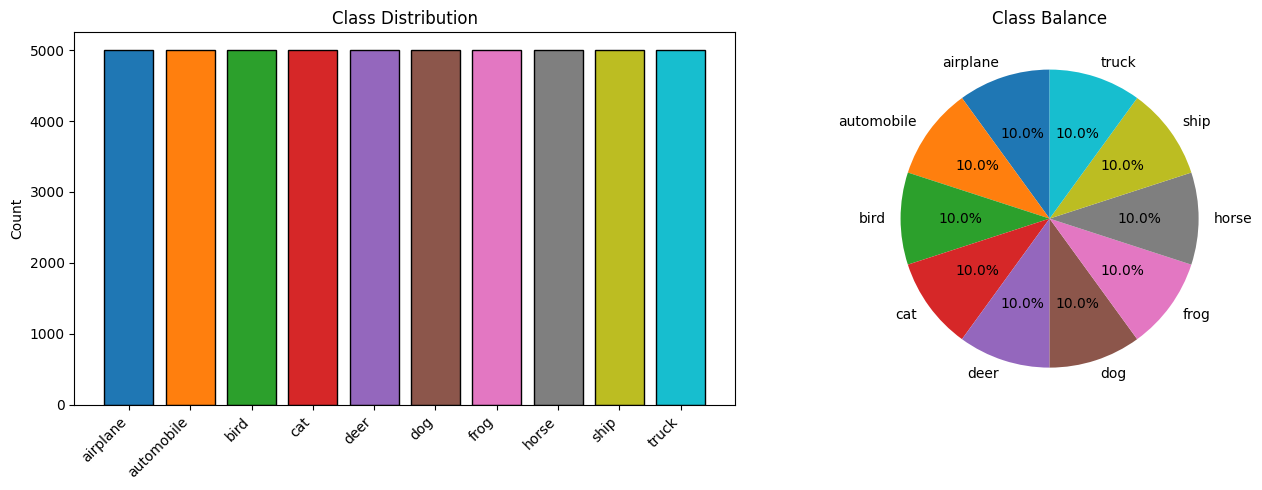

Interpretation: CIFAR-10 is balanced across all 10 classes.
DATA PREPROCESSING — CIFAR-10
Found 50000 images in directory structure.
Train / Val / Test sizes: 40000 / 5000 / 5000
Found 40000 validated image filenames belonging to 10 classes.
Found 5000 validated image filenames belonging to 10 classes.
Found 5000 validated image filenames belonging to 10 classes.
Using directory-based CIFAR dataset from /kaggle/input/datasets/ayush1220/cifar10/cifar10
EXPLORATORY DATA ANALYSIS — CIFAR-10


/tmp/ipykernel_17/2854378080.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(list(counts.keys()), rotation=45, ha='right')


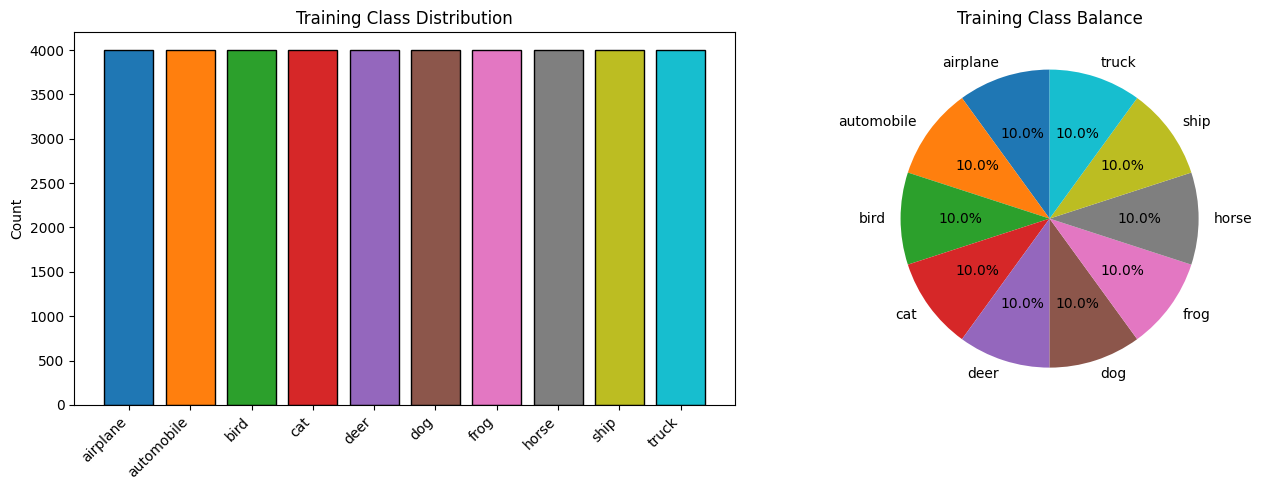

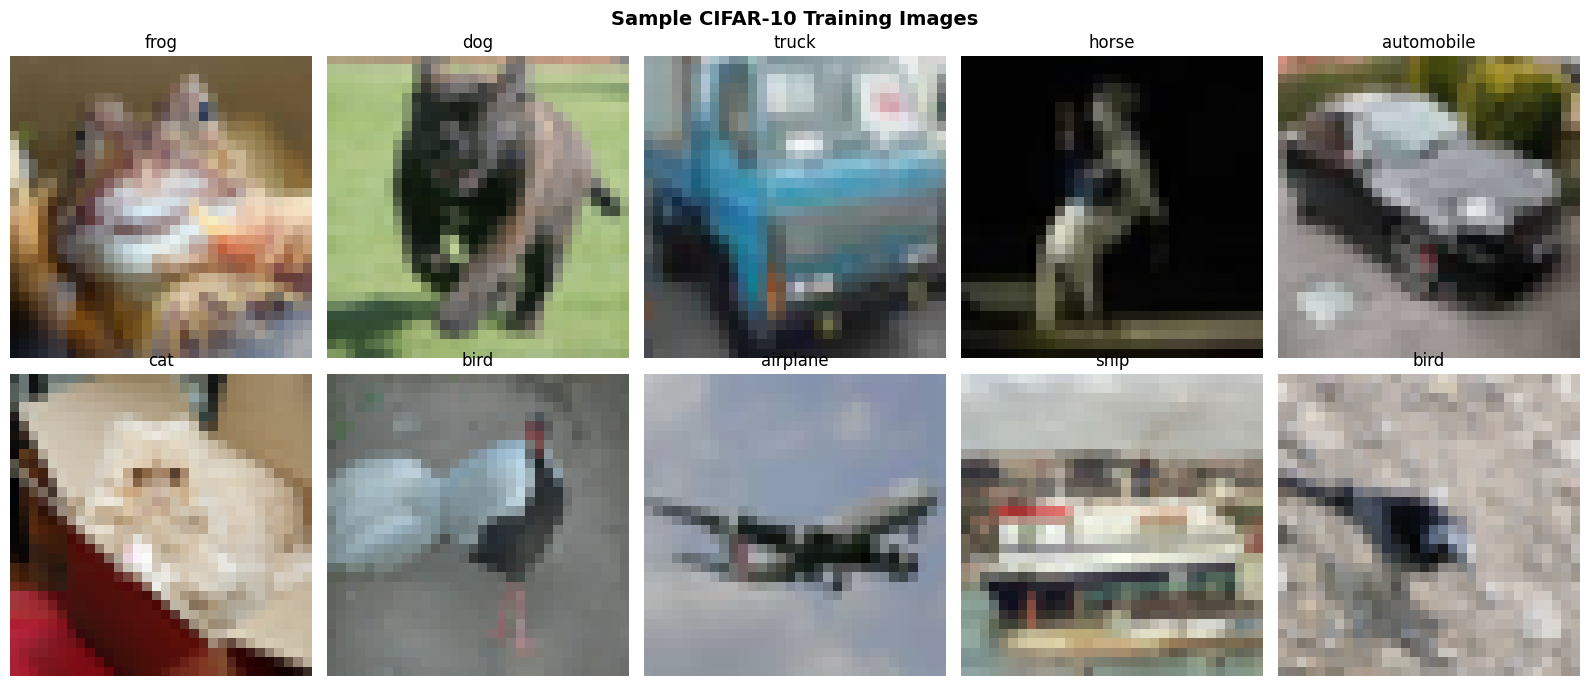

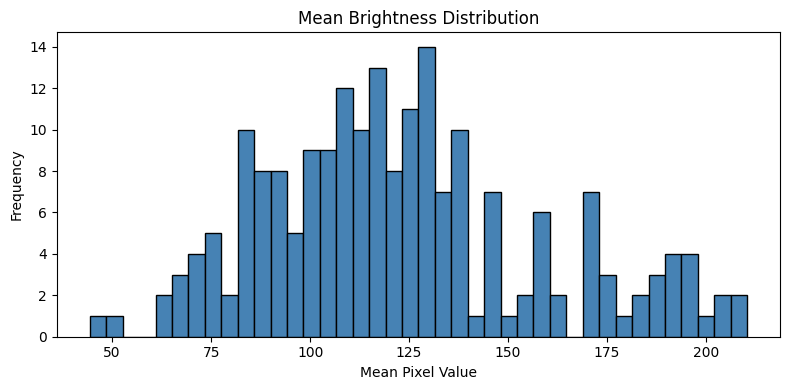

Interpretation: CIFAR brightness is varied, reflecting both indoor and outdoor scenes.


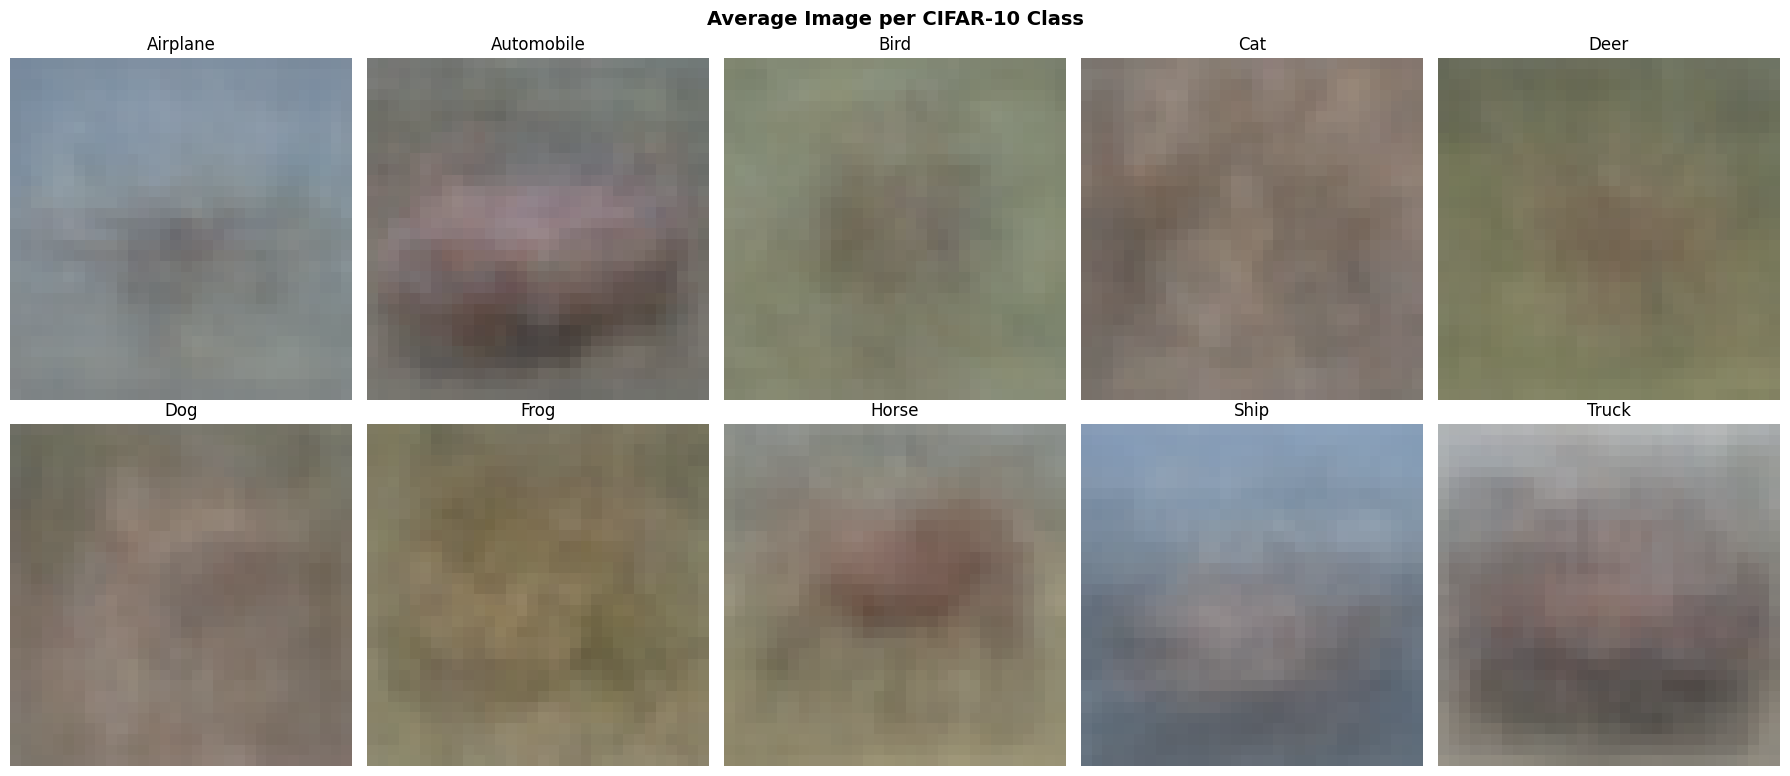

EDA complete.
FEATURE ENGINEERING & DATA AUGMENTATION — CIFAR-10


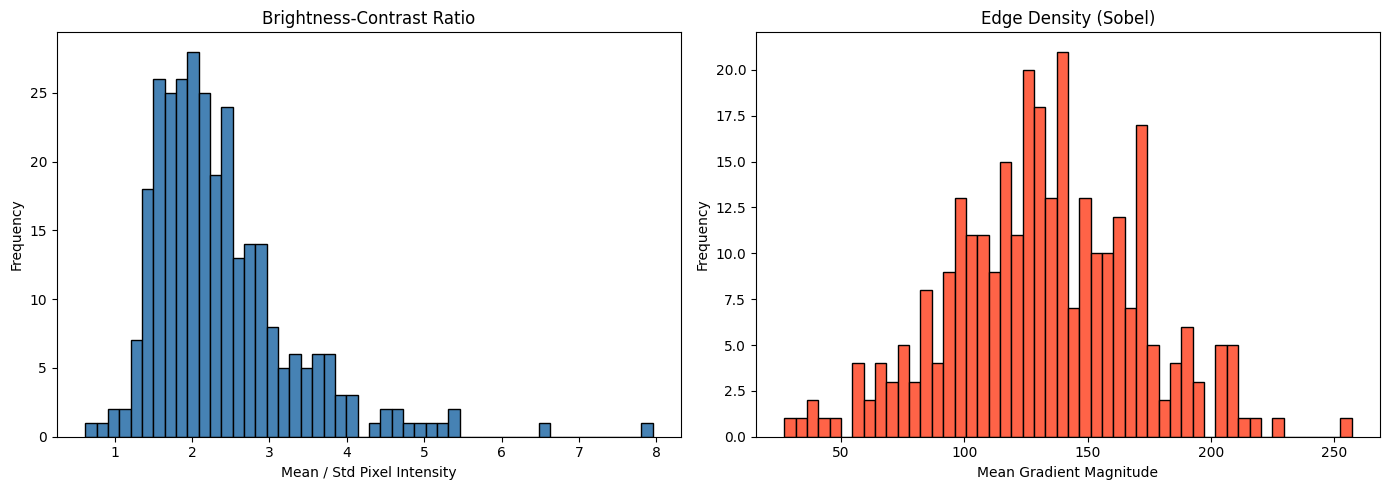

These scalar features describe image contrast and texture, but final CNNs use raw pixels.


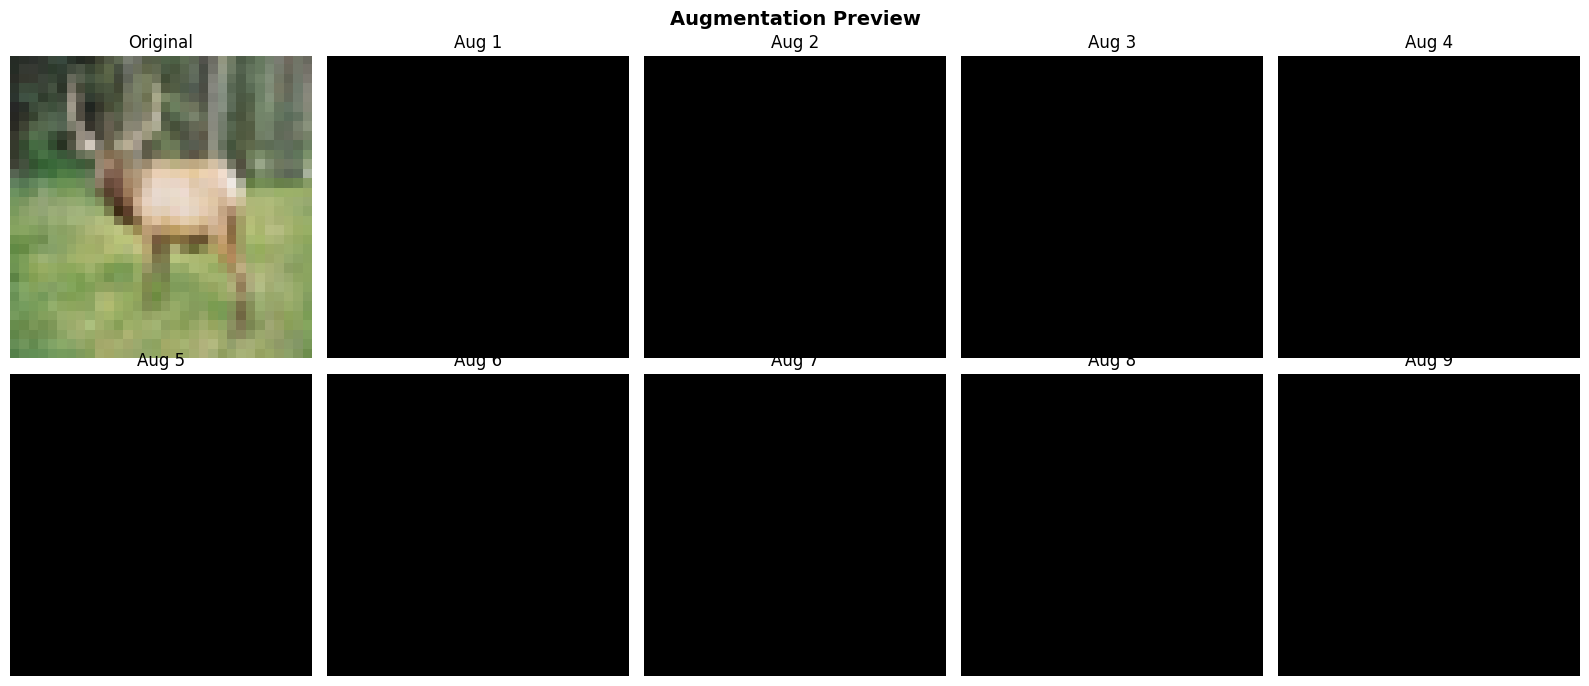

ML MODEL COMPARISON — CIFAR-10
Training classical ML on 2400 samples, test 600 samples

Training Logistic Regression
  Acc=0.2467 | Macro F1=0.2489 | Balanced Acc=0.2471

Training Decision Tree
  Acc=0.2483 | Macro F1=0.2442 | Balanced Acc=0.2488

Training Random Forest
  Acc=0.3783 | Macro F1=0.3748 | Balanced Acc=0.3800

Training SVM (RBF)
  Acc=0.4217 | Macro F1=0.4186 | Balanced Acc=0.4242

ML model comparison table:
              Model  Accuracy  Balanced Accuracy  Macro F1
          SVM (RBF)    0.4217             0.4242    0.4186
      Random Forest    0.3783             0.3800    0.3748
Logistic Regression    0.2467             0.2471    0.2489
      Decision Tree    0.2483             0.2488    0.2442


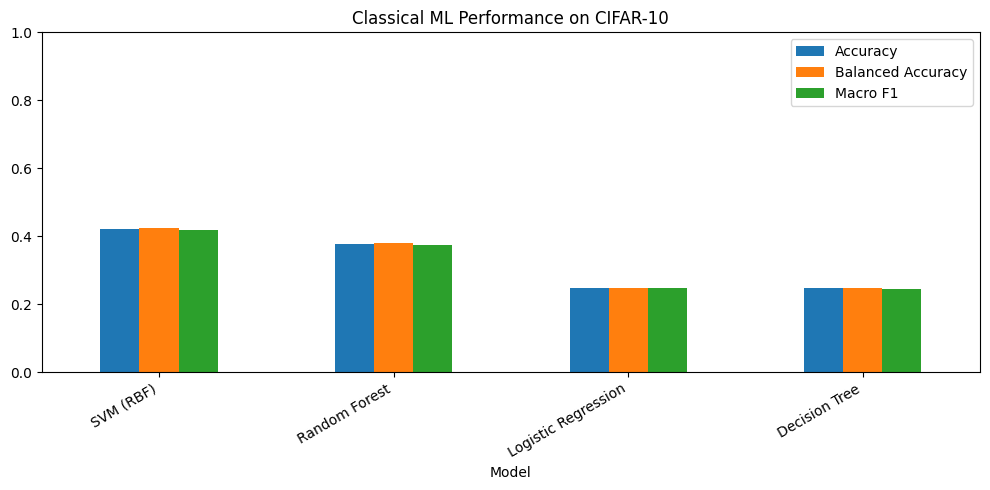

ANN MODEL PIPELINE — CIFAR-10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


ANN Test Acc=0.3606 | Balanced Acc=0.3606 | Macro F1=0.3446


,Metric,Value
0,Accuracy,0.360600
1,Balanced Accuracy,0.360600
2,Macro F1,0.344634


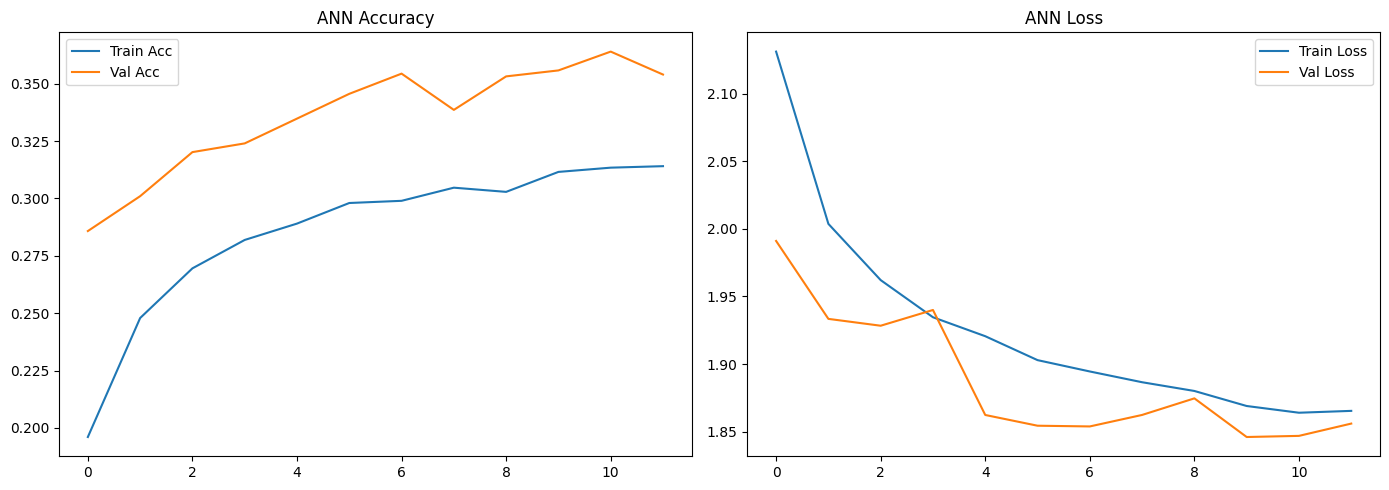

CNN MODEL PIPELINE — CIFAR-10

Training Simple CNN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Test Acc=0.7020 | Balanced Acc=0.7020 | Macro F1=0.6990

Training BN + Dropout CNN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Test Acc=0.7736 | Balanced Acc=0.7736 | Macro F1=0.7709

Training MobileNetV2


/tmp/ipykernel_17/1250950440.py:22: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  Test Acc=0.3644 | Balanced Acc=0.3644 | Macro F1=0.3591

CNN comparison table:


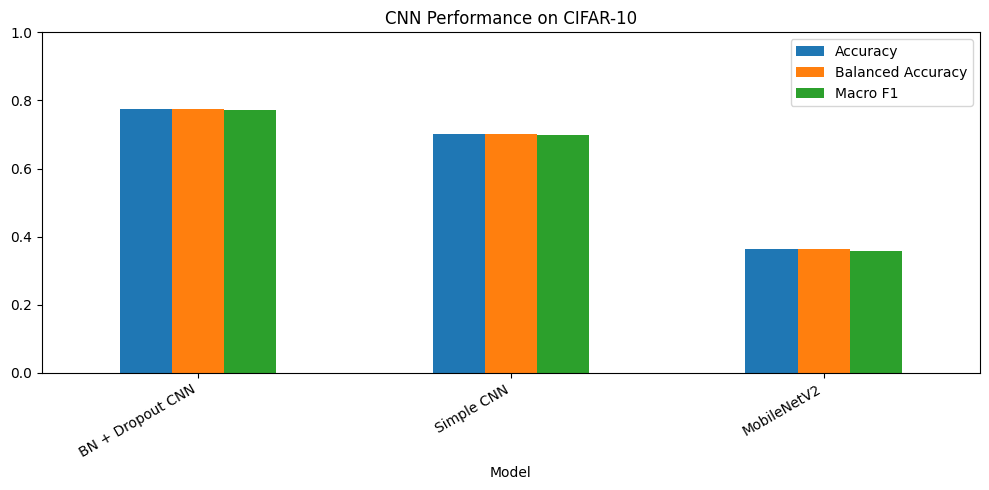

HYPERPARAMETER TUNING — CIFAR-10

Tuning LR=0.001, Dropout=0.3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Test Acc=0.7714 | Balanced Acc=0.7714 | Macro F1=0.7713

Tuning LR=0.001, Dropout=0.5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Test Acc=0.7584 | Balanced Acc=0.7584 | Macro F1=0.7597

Tuning LR=0.0005, Dropout=0.3


...

  Test Acc=0.7044 | Balanced Acc=0.7044 | Macro F1=0.7026

Training BatchNorm


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Test Acc=0.6790 | Balanced Acc=0.6790 | Macro F1=0.6855

Training Combined


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Test Acc=0.7148 | Balanced Acc=0.7148 | Macro F1=0.7164

Regularization comparison:


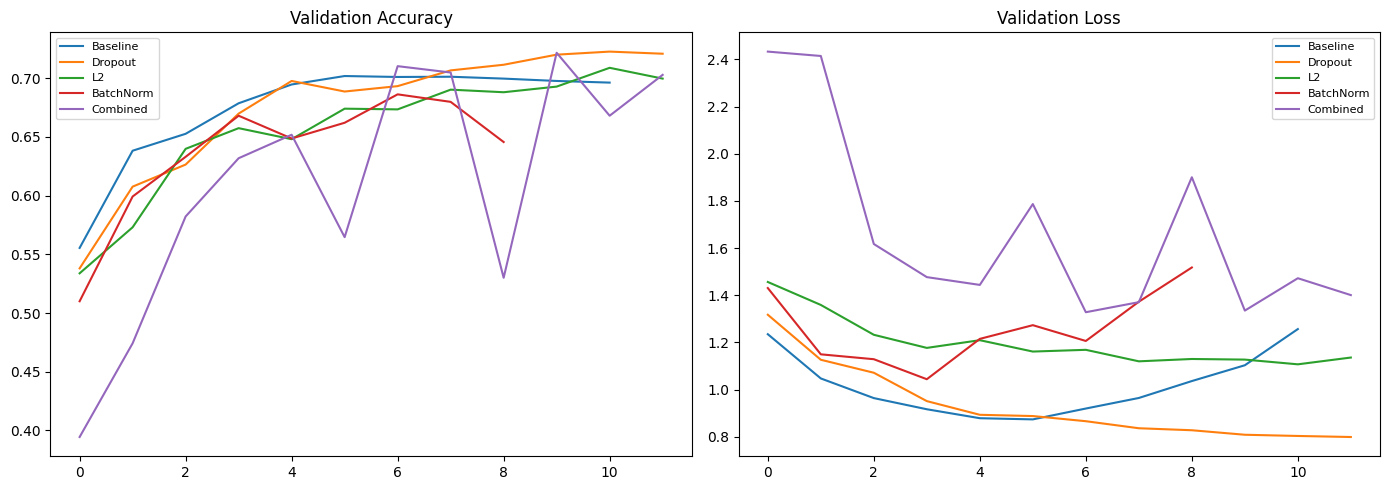

FINAL SELECTED MODEL: Tuned BN + Dropout CNN | Macro F1=0.7713
FINAL EVALUATION — Tuned BN + Dropout CNN
Accuracy=0.7714 | Balanced Acc=0.7714 | Macro F1=0.7713

Classification report:
              precision    recall  f1-score   support

    airplane       0.84      0.73      0.78       500
  automobile       0.89      0.86      0.88       500
        bird       0.58      0.75      0.66       500
         cat       0.71      0.53      0.61       500
        deer       0.63      0.79      0.70       500
         dog       0.76      0.62      0.68       500
        frog       0.83      0.87      0.85       500
       horse       0.87      0.84      0.86       500
        ship       0.79      0.92      0.85       500
       truck       0.92      0.80      0.85       500

    accuracy                           0.77      5000
   macro avg       0.78      0.77      0.77      5000
weighted avg       0.78      0.77      0.77      5000



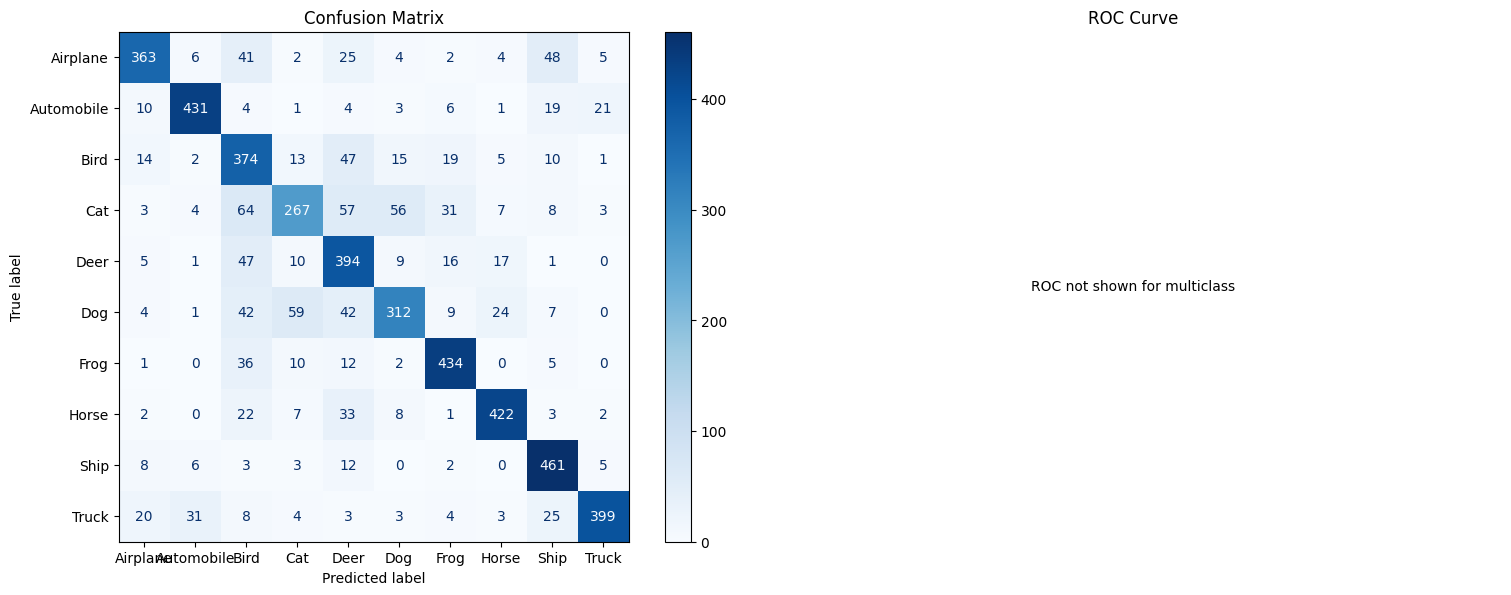

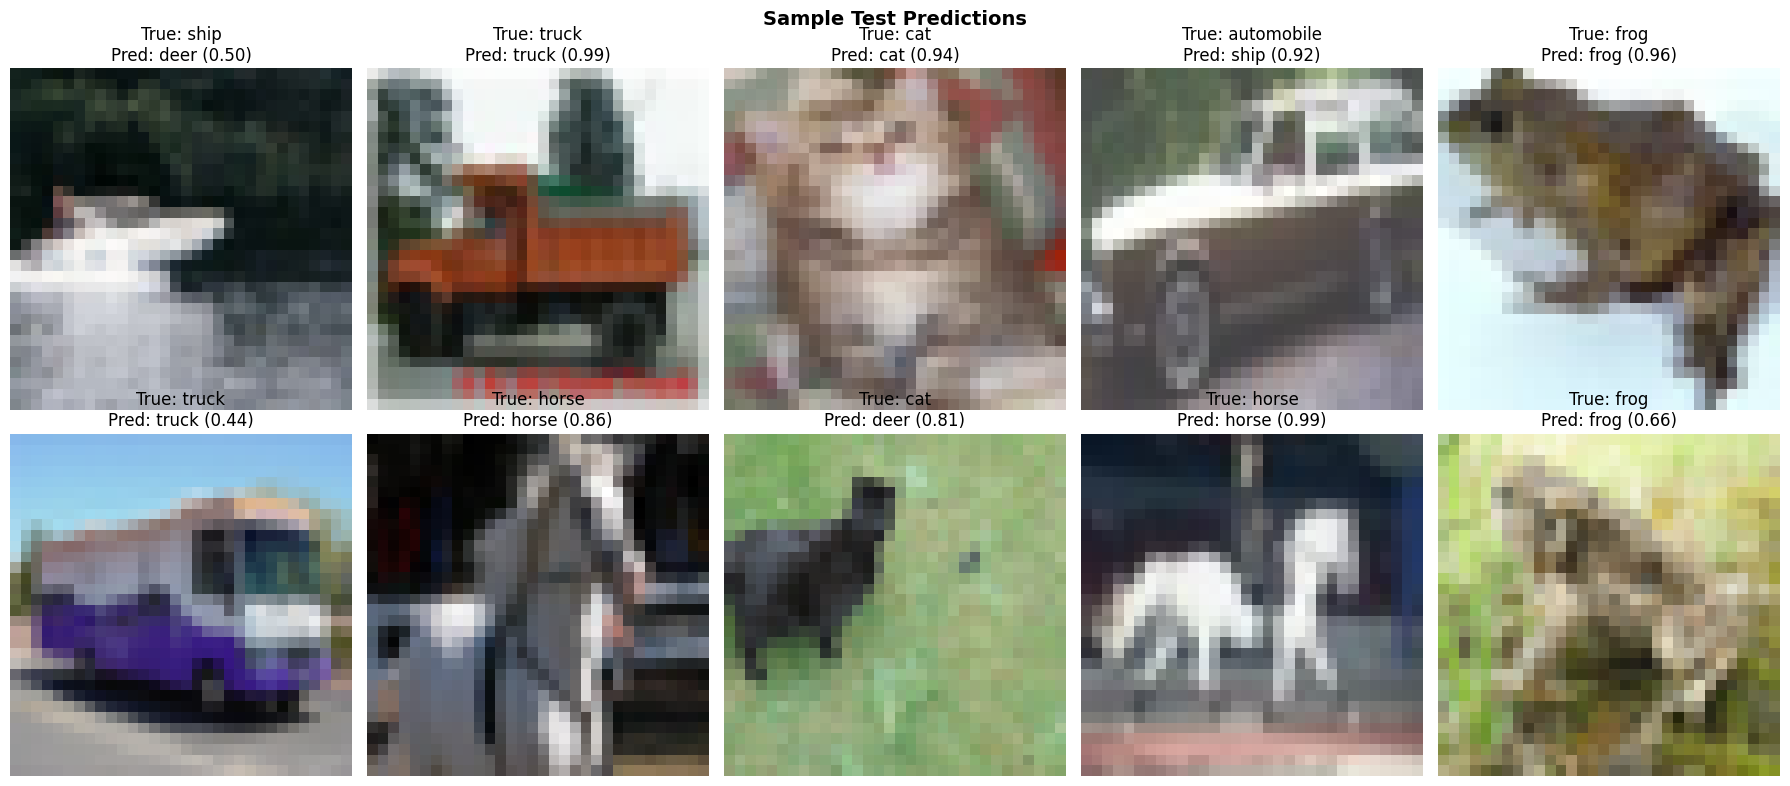

Business interpretation: automated image tagging for retail, educational benchmarking, and edge-device deployment research.
Limitations: small 32x32 images, no object localization, and multiclass confusion between visually similar categories.
Saved outputs to /kaggle/working


In [13]:
results = run_pipeline(DATA_DIR, IMG_SIZE, BATCH_SIZE, EPOCHS)
save_dir = '/kaggle/working'
os.makedirs(save_dir, exist_ok=True)
results['ml_df'].to_csv(os.path.join(save_dir, 'ml_model_comparison.csv'), index=False)
results['cnn_df'].to_csv(os.path.join(save_dir, 'cnn_model_comparison.csv'), index=False)
results['tune_df'].to_csv(os.path.join(save_dir, 'hyperparameter_tuning.csv'), index=False)
results['reg_df'].to_csv(os.path.join(save_dir, 'regularization_comparison.csv'), index=False)
results['final_model'].save(os.path.join(save_dir, 'best_cifar10_model.keras'))
print('Saved outputs to', save_dir)